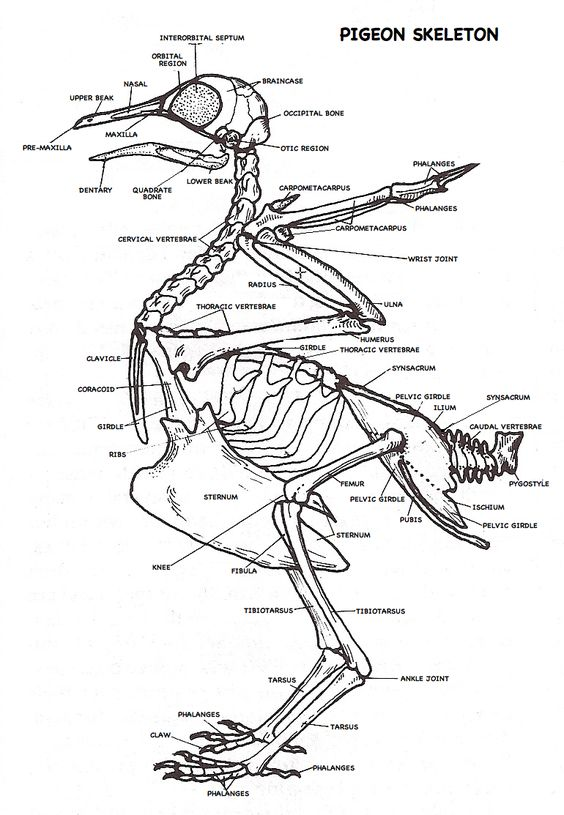

# Bird bones neural network

## Introduction

Predict a bird's ecological group from its bone measurements with an ANN, and test how two hyperparameters affect learning.

**Data**: *Birds' Bones and Living Habits* (Zhang, n.d.)
- 420 birds, 10 features: length (`l`) + diameter (`w`) of 5 wing/leg bones, in mm (bones labelled in the skeleton above)

| column | meaning |
|--------|---------|
| `id` | row number, not a feature |
| `huml` / `humw` | humerus length / diameter (wing, upper arm) |
| `ulnal` / `ulnaw` | ulna length / diameter (wing, forearm) |
| `feml` / `femw` | femur length / diameter (leg, thigh) |
| `tibl` / `tibw` | tibiotarsus length / diameter (leg, shin) |
| `tarl` / `tarw` | tarsometatarsus length / diameter (leg, lower leg above the toes) |
| `type` | ecological group (target) |

- target `type`, 6 classes, imbalanced:

| code | group | n |
|------|-------|---|
| SO | singing | 128 |
| SW | swimming | 116 |
| W  | wading | 65 |
| R  | raptors | 50 |
| P  | scansorial | 38 |
| T  | terrestrial | 23 |

## 1. Load data

Download the dataset from Kaggle and load it (local copy as fallback).

In [1]:
import os

import kagglehub
import pandas as pd

DATASET = "zhangjuefei/birds-bones-and-living-habits"
LOCAL_CSV = os.path.join("data", "bird.csv")

try:
    path = kagglehub.dataset_download(DATASET)
    csv_file = os.path.join(path, "bird.csv")
    print("Loaded from Kaggle:", csv_file)
except Exception as e:
    print("Kaggle download failed:", e)
    csv_file = LOCAL_CSV
    print("Using local fallback:", csv_file)

df = pd.read_csv(csv_file)

Loaded from Kaggle: C:\Users\mvdhe\.cache\kagglehub\datasets\zhangjuefei\birds-bones-and-living-habits\versions\1\bird.csv


In [2]:
print(df.shape)
df.head()

(420, 12)


,id,huml,humw,ulnal,ulnaw,feml,femw,tibl,tibw,tarl,tarw,type
0,0,80.78,6.68,72.01,4.88,41.81,3.70,5.50,4.03,38.70,3.84,SW
1,1,88.91,6.63,80.53,5.59,47.04,4.30,80.22,4.51,41.50,4.01,SW
2,2,79.97,6.37,69.26,5.28,43.07,3.90,75.35,4.04,38.31,3.34,SW
3,3,77.65,5.70,65.76,4.77,40.04,3.52,69.17,3.40,35.78,3.41,SW
4,4,62.80,4.84,52.09,3.73,33.95,2.72,56.27,2.96,31.88,3.13,SW


## 2. Explore data

### Missing values

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

missing = df.isna().sum()
print(missing[missing > 0])
print("Rows with missing values:", df.isna().any(axis=1).sum())

huml     1
humw     1
ulnal    3
ulnaw    2
feml     2
femw     1
tibl     2
tibw     1
tarl     1
tarw     1
dtype: int64
Rows with missing values: 7


### Class counts

type
SO    128
SW    116
W      65
R      50
P      38
T      23
Name: count, dtype: int64


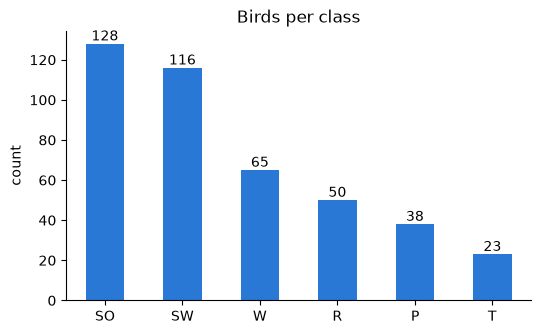

In [4]:
BLUE = "#2a78d6"
CLASS_ORDER = df["type"].value_counts().index

counts = df["type"].value_counts()
print(counts)

ax = counts.plot.bar(color=BLUE, rot=0, figsize=(6, 3.5))
ax.bar_label(ax.containers[0])
ax.set_title("Birds per class")
ax.set_xlabel("")
ax.set_ylabel("count")
ax.spines[["top", "right"]].set_visible(False)
plt.show()

### Bone measurements per class

Which features separate the groups, and where the outliers are.

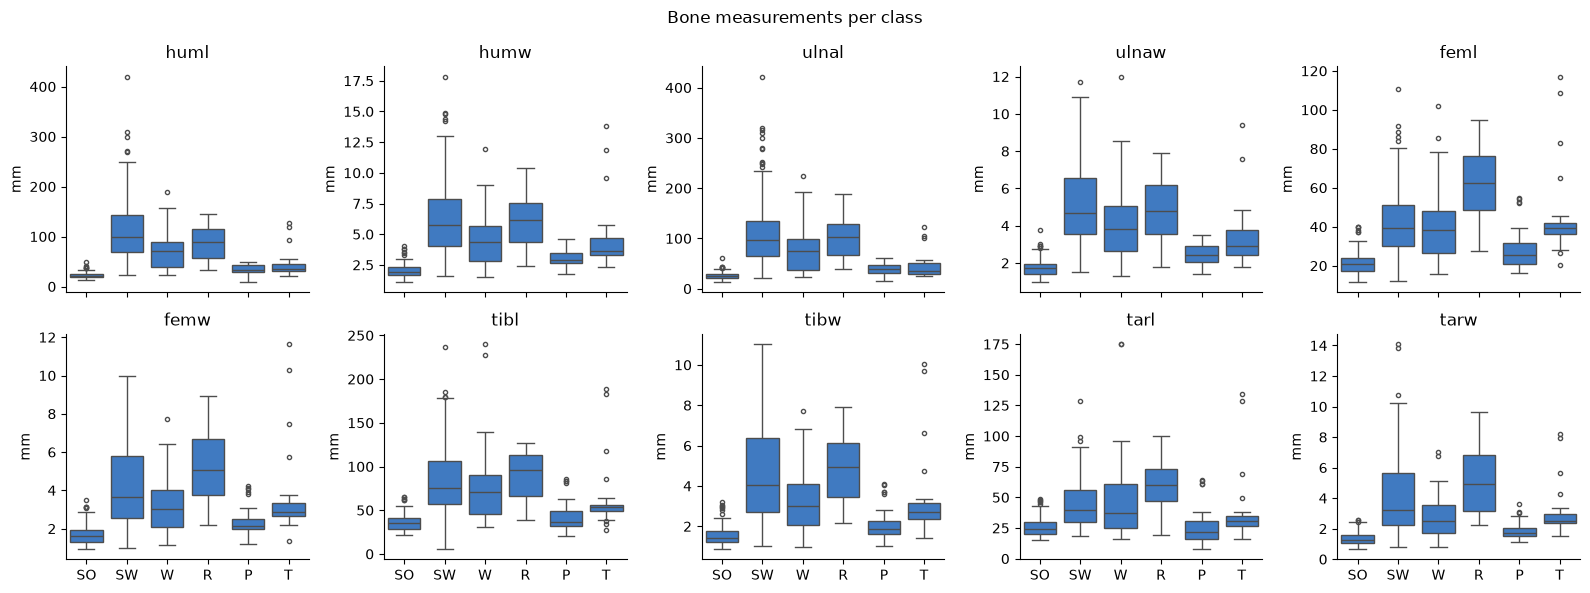

In [5]:
features = df.columns.drop(["id", "type"])

fig, axes = plt.subplots(2, 5, figsize=(16, 6), sharex=True)
for ax, col in zip(axes.flat, features):
    sns.boxplot(data=df, x="type", y=col, order=CLASS_ORDER, color=BLUE, ax=ax,
                fliersize=3, linewidth=1)
    ax.set_title(col)
    ax.set_xlabel("")
    ax.set_ylabel("mm")
    ax.spines[["top", "right"]].set_visible(False)
fig.suptitle("Bone measurements per class")
fig.tight_layout()
plt.show()

### Feature correlation

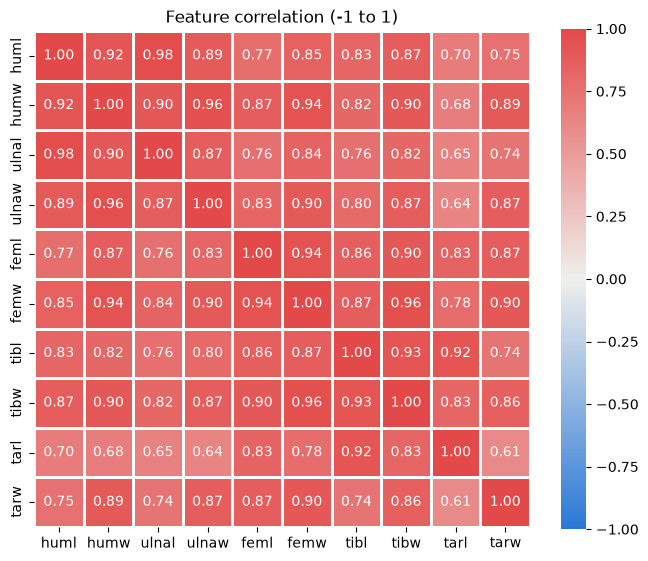

In [6]:
from matplotlib.colors import LinearSegmentedColormap

diverging = LinearSegmentedColormap.from_list("blue_red", ["#2a78d6", "#f0efec", "#e34948"])

corr = df[features].corr()
fig, ax = plt.subplots(figsize=(8, 6.5))
sns.heatmap(corr, cmap=diverging, vmin=-1, vmax=1, annot=True, fmt=".2f",
            square=True, linewidths=1, linecolor="white", ax=ax)
ax.set_title("Feature correlation (-1 to 1)")
plt.show()

Everything is positive, so this scale turns every cell red and hides the differences. Same matrix again, on a single-hue scale from 0.5 to 1.

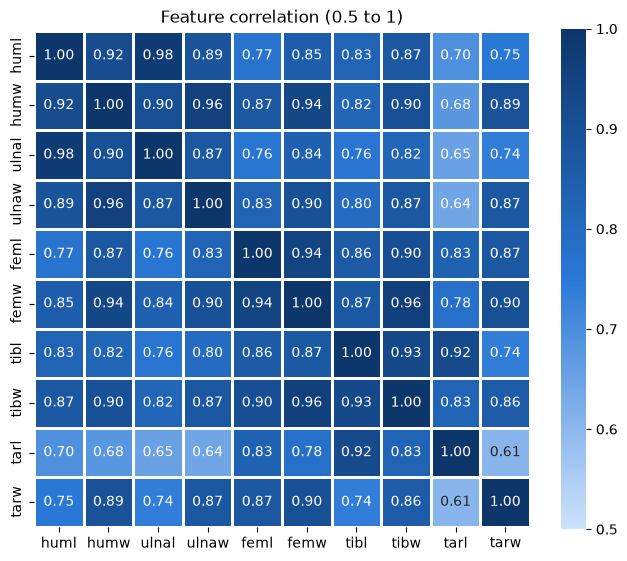

In [7]:
blues = LinearSegmentedColormap.from_list("blues", ["#cde2fb", "#2a78d6", "#0d366b"])

fig, ax = plt.subplots(figsize=(8, 6.5))
sns.heatmap(corr, cmap=blues, vmin=0.5, vmax=1, annot=True, fmt=".2f",
            square=True, linewidths=1, linecolor="white", ax=ax)
ax.set_title("Feature correlation (0.5 to 1)")
plt.show()

### Findings
- 15 missing values spread over 7 rows (< 2 %) → drop them
- imbalanced: SO has 5.6× more birds than T → stratified split
- two size groups: SO + P small, SW/W/R large, T in between → expect confusion inside each group
- features correlate 0.61–0.98: mostly overall body size; the class signal is in the proportions
- right-skewed with outliers (large SW birds); row 0 `tibl` = 5.50 mm vs ~75 for SW → likely entry error

## 3. Preprocess

### Missing values

Drop the 7 incomplete rows (< 2 % of the data) and the `id` column.

In [8]:
df_clean = df.dropna().drop(columns="id")
print(df_clean.shape)

(413, 11)


### Encode labels

Integer labels 0–5, for sparse categorical cross-entropy later.

In [9]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
X = df_clean[features].values
y = encoder.fit_transform(df_clean["type"])

print(dict(zip(encoder.classes_, range(len(encoder.classes_)))))

{'P': 0, 'R': 1, 'SO': 2, 'SW': 3, 'T': 4, 'W': 5}


### Stratified split 70 / 15 / 15

Split off 30 %, then halve that into validation and test. Stratified both times to keep the class ratios.

In [10]:
from sklearn.model_selection import train_test_split

SEED = 1

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=SEED)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=SEED)

split_counts = pd.DataFrame({
    "train": pd.Series(encoder.inverse_transform(y_train)).value_counts(),
    "val": pd.Series(encoder.inverse_transform(y_val)).value_counts(),
    "test": pd.Series(encoder.inverse_transform(y_test)).value_counts(),
})
split_counts.loc["total"] = split_counts.sum()
split_counts

,train,val,test
SO,87,19,18
SW,81,17,18
W,45,9,10
R,33,8,7
P,27,5,6
T,16,4,3
total,289,62,62


### Scale features

StandardScaler fit on train only, so no validation/test statistics leak into training.

In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

pd.DataFrame({
    "train mean": X_train.mean(axis=0),
    "train std": X_train.std(axis=0),
    "test mean": X_test.mean(axis=0),
    "test std": X_test.std(axis=0),
}, index=features).round(2)

,train mean,train std,test mean,test std
huml,0.0,1.0,-0.05,0.96
humw,0.0,1.0,-0.07,0.94
ulnal,0.0,1.0,-0.04,0.97
ulnaw,-0.0,1.0,0.02,1.08
feml,0.0,1.0,-0.15,0.89
femw,-0.0,1.0,-0.09,0.95
tibl,0.0,1.0,-0.11,0.86
tibw,0.0,1.0,-0.10,0.96
tarl,0.0,1.0,-0.10,0.88
tarw,-0.0,1.0,-0.03,1.14


## 4. Baseline model

### Architecture

10 inputs → 32 → 16 → 6 softmax. Small on purpose, only 289 training samples.

In [12]:
import keras
from keras import layers

keras.utils.set_random_seed(SEED)

N_FEATURES = X_train.shape[1]
N_CLASSES = len(encoder.classes_)


def build_model(hidden=(32, 16), learning_rate=1e-3):
    model = keras.Sequential([keras.Input(shape=(N_FEATURES,))])
    for units in hidden:
        model.add(layers.Dense(units, activation="relu"))
    model.add(layers.Dense(N_CLASSES, activation="softmax"))
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model


baseline = build_model()
baseline.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           102 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 982 (3.84 KB)

 Trainable params: 982 (3.84 KB)

 Non-trainable params: 0 (0.00 B)

### Train

Adam, lr 0.001, batch 32. EarlyStopping on validation loss (patience 30) restores the best weights, so the epoch count doesn't have to be tuned.

In [13]:
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=30, restore_best_weights=True)

history = baseline.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=1000,
    batch_size=32,
    callbacks=[early_stop],
    verbose=0,
)

best_epoch = early_stop.best_epoch + 1
print("Stopped after", len(history.history["loss"]), "epochs, best epoch:", best_epoch)
print("Val loss:", round(min(history.history["val_loss"]), 3))
print("Val accuracy:", round(history.history["val_accuracy"][best_epoch - 1], 3))

Stopped after 335 epochs, best epoch: 305
Val loss: 0.438
Val accuracy: 0.887


### Learning curves

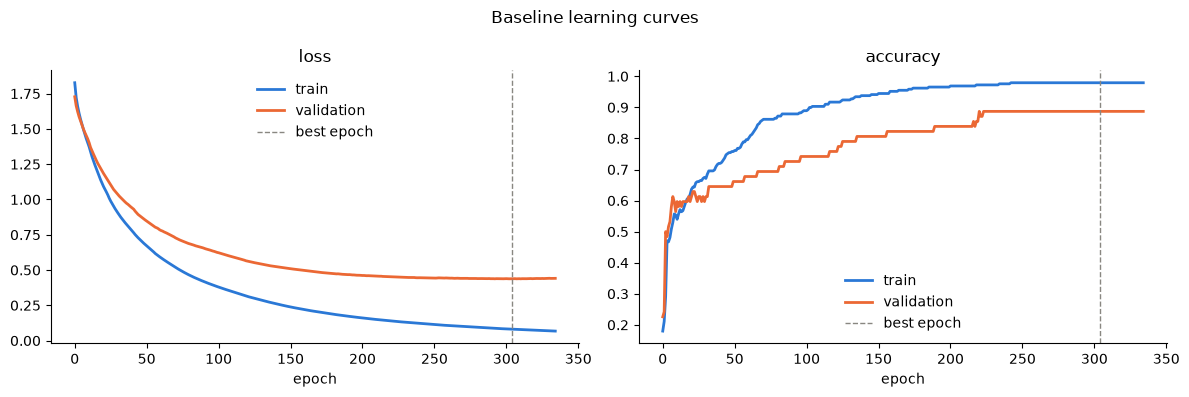

In [14]:
ORANGE = "#eb6834"
GREY = "#898781"


def plot_history(history, best_epoch, title):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for ax, metric in zip(axes, ["loss", "accuracy"]):
        ax.plot(history.history[metric], color=BLUE, linewidth=2, label="train")
        ax.plot(history.history["val_" + metric], color=ORANGE, linewidth=2, label="validation")
        ax.axvline(best_epoch - 1, color=GREY, linestyle="--", linewidth=1, label="best epoch")
        ax.set_title(metric)
        ax.set_xlabel("epoch")
        ax.spines[["top", "right"]].set_visible(False)
        ax.legend(frameon=False)
    fig.suptitle(title)
    fig.tight_layout()
    plt.show()


plot_history(history, best_epoch, "Baseline learning curves")

### Observations
- val loss flattens around epoch 250, train loss keeps dropping. gap = start of overfitting; EarlyStopping catches it (best epoch 305)
- train accuracy 0.98 vs validation 0.89
- val accuracy moves in steps of 1/62 ≈ 1.6 %: small validation set, so single birds swing the score

## 5. Hyperparameter experiments

Each setting is trained with seeds 1, 2 and 3 on the same split and reported as mean ± std, so a difference isn't just one lucky run. Max 2000 epochs so slow settings can still converge before EarlyStopping.

### Setup

In [15]:
SEEDS = [1, 2, 3]
AQUA = "#1baf7a"


def train_model(hidden=(32, 16), learning_rate=1e-3, seed=SEED):
    keras.utils.set_random_seed(seed)
    model = build_model(hidden, learning_rate)
    early_stop = keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=30, restore_best_weights=True)
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=2000,
        batch_size=32,
        callbacks=[early_stop],
        verbose=0,
    )
    return model, history, early_stop.best_epoch + 1


def summarise(results, setting):
    table = results.groupby(setting, sort=False)[["best epoch", "val loss", "val accuracy"]]
    return table.agg(["mean", "std"]).round(3)


def plot_experiment(histories, settings, labels, title):
    colors = [BLUE, ORANGE, AQUA]
    fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
    for ax, metric in zip(axes, ["loss", "val_loss"]):
        for setting, label, color in zip(settings, labels, colors):
            for seed in SEEDS:
                values = histories[(setting, seed)].history[metric]
                ax.plot(range(1, len(values) + 1), values, color=color, linewidth=1.5,
                        label=label if seed == SEEDS[0] else None)
        ax.set_title("train loss" if metric == "loss" else "validation loss")
        ax.set_xlabel("epoch")
        ax.set_xscale("log")
        ax.spines[["top", "right"]].set_visible(False)
    axes[0].legend(frameon=False)
    fig.suptitle(title + ", 3 seeds each (log x-axis)")
    fig.tight_layout()
    plt.show()

### Learning rate

0.01 / 0.001 / 0.0001, everything else as the baseline (0.001 with seed 1 = the baseline run).

In [16]:
LEARNING_RATES = [1e-2, 1e-3, 1e-4]

lr_rows = []
lr_histories = {}
for lr in LEARNING_RATES:
    for seed in SEEDS:
        _, history, best_epoch = train_model(learning_rate=lr, seed=seed)
        lr_histories[(lr, seed)] = history
        lr_rows.append({
            "learning rate": lr,
            "seed": seed,
            "best epoch": best_epoch,
            "val loss": history.history["val_loss"][best_epoch - 1],
            "val accuracy": history.history["val_accuracy"][best_epoch - 1],
        })

lr_results = pd.DataFrame(lr_rows)
display(lr_results.round(3))
summarise(lr_results, "learning rate")

,learning rate,seed,best epoch,val loss,val accuracy
0,0.010,1,54,0.421,0.855
1,0.010,2,49,0.289,0.903
2,0.010,3,82,0.402,0.887
3,0.001,1,305,0.438,0.887
4,0.001,2,447,0.242,0.919
5,0.001,3,375,0.538,0.839
6,0.000,1,1856,0.558,0.806
7,0.000,2,2000,0.317,0.855
8,0.000,3,2000,0.606,0.806


best epoch         val loss        val accuracy       
                    mean     std     mean    std         mean    std
learning rate                                                       
0.0100            61.667  17.786    0.371  0.071        0.882  0.025
0.0010           375.667  71.002    0.406  0.150        0.882  0.041
0.0001          1952.000  83.138    0.494  0.155        0.823  0.028

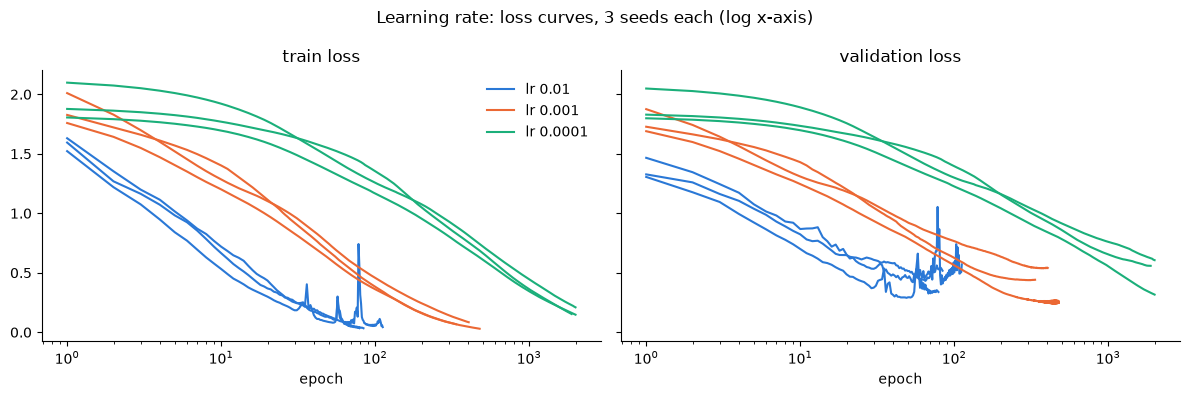

In [17]:
plot_experiment(lr_histories, LEARNING_RATES, [f"lr {lr:g}" for lr in LEARNING_RATES],
                "Learning rate: loss curves")

**Observations, learning rate**
- 0.01: converges in ~60 epochs, lowest val loss (0.371) and smallest spread, but spiky curves and quick overfitting after the minimum
- 0.001: same accuracy (0.882), ~6× more epochs, smooth curves; largest spread between seeds (val loss 0.24–0.54)
- 0.0001: too slow, 2 of 3 runs still improving at the 2000-epoch cap → not converged, lowest accuracy (0.823)
- accuracy 0.01 vs 0.001 is equal; the seed spread is bigger than the difference between them

### Network size

Hidden layers 8 / 32-16 / 128-64 at lr 0.001: from small to clearly oversized for 289 samples. 32-16 is the baseline.

In [18]:
SIZES = [(8,), (32, 16), (128, 64)]
SIZE_LABELS = ["-".join(str(units) for units in hidden) for hidden in SIZES]

size_rows = []
size_histories = {}
for hidden, label in zip(SIZES, SIZE_LABELS):
    for seed in SEEDS:
        model, history, best_epoch = train_model(hidden=hidden, seed=seed)
        size_histories[(hidden, seed)] = history
        size_rows.append({
            "hidden layers": label,
            "params": model.count_params(),
            "seed": seed,
            "best epoch": best_epoch,
            "val loss": history.history["val_loss"][best_epoch - 1],
            "val accuracy": history.history["val_accuracy"][best_epoch - 1],
        })

size_results = pd.DataFrame(size_rows)
display(size_results.round(3))
summarise(size_results, "hidden layers")

,hidden layers,params,seed,best epoch,val loss,val accuracy
0,8,142,1,1463,0.548,0.806
1,8,142,2,900,0.554,0.839
2,8,142,3,909,0.625,0.823
3,32-16,982,1,305,0.438,0.887
4,32-16,982,2,447,0.242,0.919
5,32-16,982,3,375,0.538,0.839
6,128-64,10054,1,149,0.333,0.887
7,128-64,10054,2,155,0.399,0.887
8,128-64,10054,3,116,0.552,0.871


best epoch          val loss        val accuracy       
                    mean      std     mean    std         mean    std
hidden layers                                                        
8               1090.667  322.482    0.576  0.043        0.823  0.016
32-16            375.667   71.002    0.406  0.150        0.882  0.041
128-64           140.000   21.000    0.428  0.113        0.882  0.009

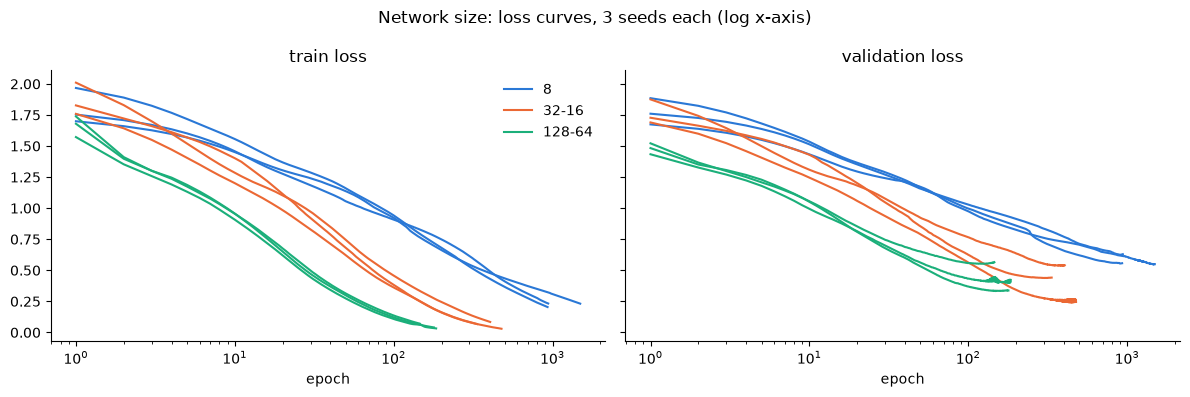

In [19]:
plot_experiment(size_histories, SIZES, SIZE_LABELS, "Network size: loss curves")

**Observations, network size**
- 8 (142 params): underfits: highest val loss (0.576), lowest accuracy (0.823), needs ~1100 epochs
- 32-16 and 128-64 reach the same mean accuracy (0.882); 128-64 converges fastest (~140 epochs) and is the most stable (accuracy std 0.009)
- 128-64 has 10k params for 289 samples and still doesn't do worse: EarlyStopping keeps the overfitting in check
- by val loss 32-16 (0.406) wins narrowly over 128-64 (0.428), within the seed spread

## 6. Final evaluation

### Final model

Best learning rate and network size by mean validation loss, retrained with seed 1. First and only time the test set is used.

Learning rate: 0.01 | hidden layers: (32, 16)


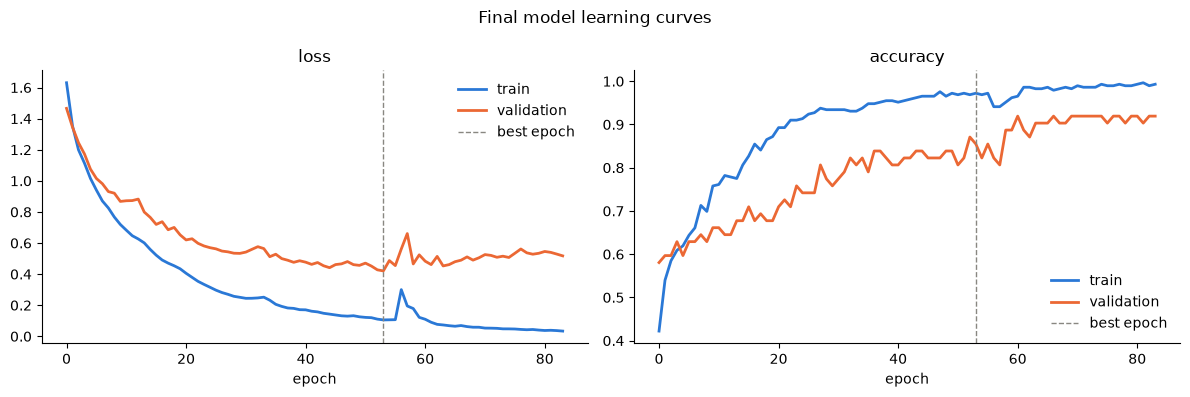

In [20]:
lr_val_loss = lr_results.groupby("learning rate")["val loss"].mean()
size_val_loss = size_results.groupby("hidden layers")["val loss"].mean()

best_lr = lr_val_loss.idxmin()
best_hidden = SIZES[SIZE_LABELS.index(size_val_loss.idxmin())]
print("Learning rate:", best_lr, "| hidden layers:", best_hidden)

final_model, final_history, final_best_epoch = train_model(hidden=best_hidden, learning_rate=best_lr)
plot_history(final_history, final_best_epoch, "Final model learning curves")

### Test results

In [21]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = final_model.predict(X_test, verbose=0).argmax(axis=1)

print("Test accuracy:", round(accuracy_score(y_test, y_pred), 3))
print(classification_report(y_test, y_pred, target_names=encoder.classes_, digits=3))

Test accuracy: 0.903
              precision    recall  f1-score   support

           P      0.833     0.833     0.833         6
           R      1.000     0.857     0.923         7
          SO      0.947     1.000     0.973        18
          SW      0.857     1.000     0.923        18
           T      0.667     0.667     0.667         3
           W      1.000     0.700     0.824        10

    accuracy                          0.903        62
   macro avg      0.884     0.843     0.857        62
weighted avg      0.911     0.903     0.900        62



### Confusion matrix

Classes ordered by body size (small: SO, P, T | large: SW, W, R), so confusion inside the size groups shows up as blocks.

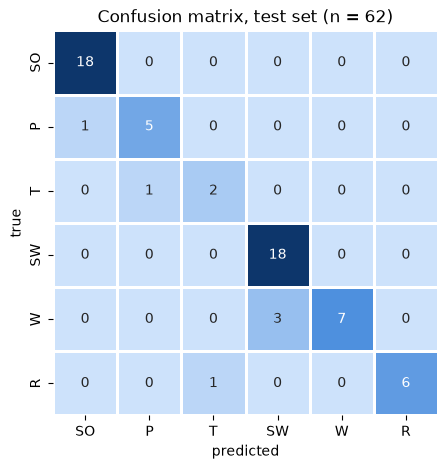

In [22]:
SIZE_ORDER = ["SO", "P", "T", "SW", "W", "R"]

cm = confusion_matrix(y_test, y_pred, labels=encoder.transform(SIZE_ORDER))

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, cmap=blues, annot=True, fmt="d", square=True, cbar=False,
            linewidths=1, linecolor="white",
            xticklabels=SIZE_ORDER, yticklabels=SIZE_ORDER, ax=ax)
ax.set_xlabel("predicted")
ax.set_ylabel("true")
ax.set_title(f"Confusion matrix, test set (n = {len(y_test)})")
plt.show()

### Discussion
- test accuracy 0.903 (56/62); macro F1 0.857 < accuracy → weaker on the small classes
- 5 of 6 errors stay inside a size group: W → SW (3×), P → SO, T → P; only R → T crosses groups. Matches the exploration: overall size separates the groups, proportions within a group are harder
- W has the lowest recall (0.70): wading and swimming birds are both large with similar bone sizes
- SO and SW perfect recall: biggest classes and the most distinct sizes
- T (3 test birds) and P (6): one error = 33 % / 17 % recall, so their per-class scores are not reliable

## 7. Reflection

- first time building a neural network; most interesting part was the architecture: how layers, neurons and the learning rate change the way the model learns
- preprocessing, stratified splitting and scaling were familiar from earlier courses
- next time: cross-validation instead of one fixed split, since a test set of 62 birds (only 3 T) makes the scores sensitive to single birds

## References

- Zhang, J. (n.d.). *Birds' Bones and Living Habits* [Data set]. Kaggle. Retrieved September 24, 2026, from https://www.kaggle.com/datasets/zhangjuefei/birds-bones-and-living-habits
- Kaggle. (n.d.). *kagglehub* [Computer software]. GitHub. Retrieved September 24, 2026, from https://github.com/Kaggle/kagglehub